In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.svm import SVR

Academic Integrity and Learning Statement

By submitting my work, I confirm that:

1. The code, analysis, and documentation in this notebook are my own work and reflect my own understanding.
2. I am prepared to explain all code and analysis included in this submission.

If I used assistance (e.g., AI tools, tutors, or other resources), I have:

- Clearly documented where and how external tools or resources were used in my solution.
- Included a copy of the interaction (e.g., AI conversation or tutoring notes) in an appendix.

I acknowledge that:

- I may be asked to explain any part of my code or analysis during evaluation.
- Misrepresenting assisted work as my own constitutes academic dishonesty and undermines my learning.


### Load the data

In [2]:
df = pd.read_csv('train_data.csv')
df.head()

,MW,LogP,NumHDonors,NumHAcceptors,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,...,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047,pIC50
0,279.273,1.74780,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.000000
1,508.626,4.75440,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.522879
2,317.755,3.45850,3.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.863279
3,506.606,4.81712,3.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.040959
4,542.854,5.73340,2.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000000


#### Preparing Features and Target Variables and Checking Their Shapes

In [3]:
X = df.drop('pIC50',  axis=1)
Y = df['pIC50']

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

Shape of X: (16937, 2052)
Shape of Y: (16937,)


#### Removing low variance features

In [4]:
selection = VarianceThreshold(threshold=(0.02))  
X_var = selection.fit_transform(X)
X_var.shape

(16937, 511)

#### Splliting the data into train and validation (into 80:20)

In [5]:
X_train_us, X_val_us, Y_train_us, Y_val_us = train_test_split(X_var, Y, test_size=0.2, random_state=42)

#### Scalling the data

In [6]:
scaler_x = StandardScaler()
X_train = scaler_x.fit_transform(X_train_us)
X_val = scaler_x.transform(X_val_us)

scaler_y = StandardScaler()
Y_train = scaler_y.fit_transform(Y_train_us.values.reshape(-1, 1)).flatten()
Y_val = scaler_y.transform(Y_val_us.values.reshape(-1, 1)).flatten()

print("Shape of X_train:", X_train.shape, "Shape of Y_train:", Y_train.shape)
print("Shape of X_val:", X_val.shape, "Shape of Y_val:", Y_val.shape)

Shape of X_train: (13549, 511) Shape of Y_train: (13549,)
Shape of X_val: (3388, 511) Shape of Y_val: (3388,)


## Support Vector Regression(SVR)

In [7]:
svm_model = SVR(kernel='rbf', C=10, epsilon=0.1)
svm_model.fit(X_train, Y_train)


SVR(C=10)

Eevaluates its performance using MSE, RMSE, and R² on both training and validation datasets.

In [8]:
y_val_pred_scaled = svm_model.predict(X_val)
y_train_pred_scaled = svm_model.predict(X_train)

y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).flatten()
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()

svm_val_mse = mean_squared_error(Y_val_us, y_val_pred)
svm_train_mse = mean_squared_error(Y_train_us, y_train_pred)

svm_val_rmse = np.sqrt(svm_val_mse)
svm_train_rmse = np.sqrt(svm_train_mse)

svm_val_r2 = r2_score(Y_val_us, y_val_pred)
svm_train_r2 = r2_score(Y_train_us, y_train_pred)

print(f"Support Vector Regression")
print(f"Validation MSE: {svm_val_mse:.4f}")
print(f"Training MSE: {svm_train_mse:.4f}")

print(f"Validation RMSE: {svm_val_rmse:.4f}")
print(f"Training RMSE: {svm_train_rmse:.4f}")

print(f"Validation R2: {svm_val_r2:.4f}")
print(f"Training R2: {svm_train_r2:.4f}")


Support Vector Regression
Validation MSE: 0.5752
Training MSE: 0.0314
Validation RMSE: 0.7584
Training RMSE: 0.1771
Validation R2: 0.7155
Training R2: 0.9842


It is observed from above data that RMSE and MSE of valid data is more than train data so I will go for hyperparameter tunning to improve performance.

### Hyperparameter Tuning 

GridSearchCV with Cross-Validation


In [9]:
pipeline = Pipeline([
    ('svr', SVR())
])
param_grid = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__epsilon': [0.01, 0.1, 0.5, 1.0],
    'svr__gamma': ['scale', 0.01, 0.1, 1]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=2,
    n_jobs=-1
)
grid_search.fit(X_train, Y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV RMSE:", np.sqrt(-grid_search.best_score_))

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best Parameters: {'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 'scale'}
Best CV RMSE: 0.5545446111807157


### Model Evaluation after tunning: RMSE and R² Score Calculation

In [10]:
best_svr_model = grid_search.best_estimator_

y_val_pred = best_svr_model.predict(X_val)
Y_val_us_pred = scaler_y.inverse_transform(y_val_pred.reshape(-1, 1)).flatten()
best_svr_val_mse = mean_squared_error(Y_val_us, Y_val_us_pred)
best_svr_val_rmse = np.sqrt(best_svr_val_mse)
best_svr_val_r2 = r2_score(Y_val_us, Y_val_us_pred)

print(f"Best SVR Model")
print(f"Validation MSE: {best_svr_val_mse:.4f}")
print(f"Validation RMSE: {best_svr_val_rmse:.4f}")
print(f"Validation R2: {best_svr_val_r2:.4f}")

Best SVR Model
Validation MSE: 0.5752
Validation RMSE: 0.7584
Validation R2: 0.7155


## Test Data

In [11]:
df_test = pd.read_csv('test_data.csv')
X_test = df_test.drop('pIC50', axis=1)
Y_test = df_test['pIC50']

print("Shape of X_test:", X_test.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_test: (4235, 2052)
Shape of Y_test: (4235,)


Here, the data is first inverse-transformed to ensure consistency across all models, since scaling was not applied to the Random Forest model and after that evaluating the MSE, RMSE and R2 on test data

In [12]:
X_test_var = selection.transform(X_test)
X_test_scaled = scaler_x.transform(X_test_var)

y_test_pred = best_svr_model.predict(X_test_scaled)
y_test_pred = scaler_y.inverse_transform(y_test_pred.reshape(-1, 1)).flatten()
test_mse = mean_squared_error(Y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(Y_test, y_test_pred)
print("Test Set Performance:")
print(f"Test MSE: {test_mse}")
print(f"Test RMSE: {test_rmse}")
print(f"Test R^2: {test_r2}")

Test Set Performance:
Test MSE: 0.5847898256392512
Test RMSE: 0.7647155194183333
Test R^2: 0.6997855073664585


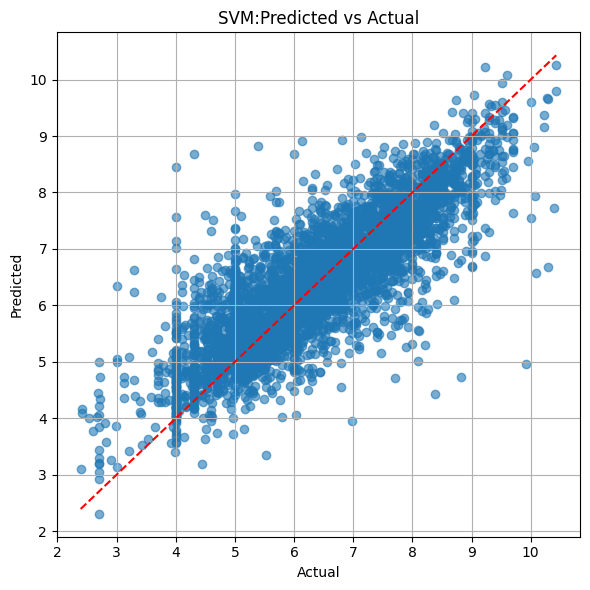

In [13]:
plt.figure(figsize=(6, 6))
plt.scatter(Y_test, y_test_pred, alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('SVM:Predicted vs Actual')
plt.grid(True)
plt.tight_layout()
plt.show()

This plot is also showing almost the similar behaviour from Random forest. However, this plot is showing more symmetrical datapoints along the diagonal line.

Saving the test RMSE and R-square score for final comparasion in the final task

In [14]:
def save_model_info(model_name, test_accuracy_rmse, r2 ):
    with open("model_info.txt", "a") as file:
        file.write(f"{model_name},{test_accuracy_rmse:.4f}, {r2:.4f}\n")

save_model_info("SVR", test_rmse, test_r2)

## Appendix

AI tools are being used to optimize some codes, below interactions are being passed to it:
1. Correct the code
2. Optimize the code